#**Logistic Regression**

#*Import Library*

In [44]:
import pandas as pd
import numpy as np

# preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

#*Load Data*

In [25]:
df = pd.read_csv('breast_cancer_data.csv')

In [26]:
df.head()

,Age,Gender,Family History,Dietary Habit,Radius,Texture,Perimeter,Area,Compactness,Concavity,Concave Points,Symmetry,Diagnosis
0,83,Female,No,Bad,12.59,27.20,75.58,478.92,0.2462,0.2443,0.0634,0.2035,Benign
1,35,Female,Yes,Good,29.00,27.54,185.73,2831.55,0.1058,0.2934,0.0943,0.1425,Malignant
2,81,Female,Yes,Good,13.43,21.76,78.05,609.84,0.2997,0.2113,0.1957,0.2697,Benign
3,20,Female,No,Good,10.21,38.22,61.60,333.74,0.1605,0.1887,0.1675,0.1585,Benign
4,47,Female,No,Bad,17.85,20.40,112.63,1008.39,0.1977,0.3115,0.0533,0.2050,Benign


#*Data Cleaning and Encoding*

In [29]:
# encode target
df['Diagnosis'] = df['Diagnosis'].map({
    'Benign': 0,
    'Malignant': 1
})

# jika ada gender
if 'gender' in df.columns:
    df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

#*Feature Selection*

In [30]:
features = [
    'Radius', 'Texture', 'Area', 'Perimeter',
    'Compactness', 'Concavity', 'Concave Points', 'Symmetry'
]

X = df[features]
y = df['Diagnosis']

#*Train-Test Split*

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#*Feature Scaling*

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#*Train Model*

In [33]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

#*Prediction*

In [34]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

#*Model Evaluation*

In [36]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.772


In [37]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86       734
           1       0.63      0.35      0.45       266

    accuracy                           0.77      1000
   macro avg       0.71      0.64      0.65      1000
weighted avg       0.75      0.77      0.75      1000



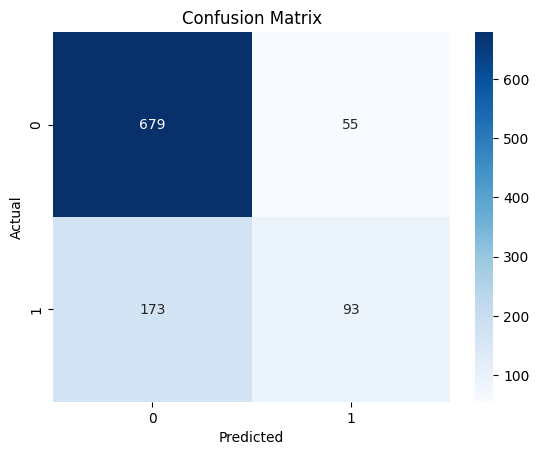

In [38]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

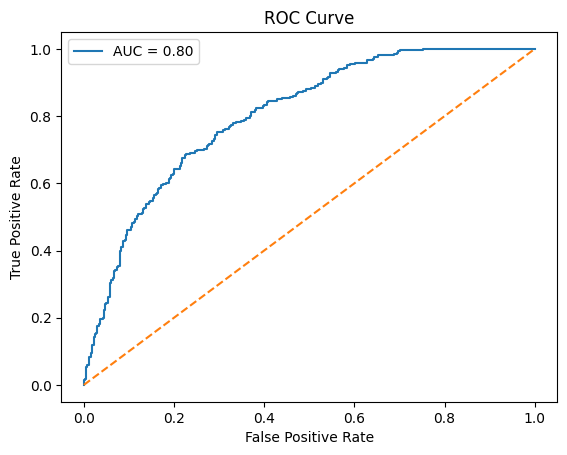

In [39]:
#ROV Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

#*Feature Importance*

          Feature  Coefficient
0          Radius     0.758724
5       Concavity     0.735769
2            Area     0.228836
4     Compactness     0.018177
3       Perimeter     0.002065
7        Symmetry    -0.007743
6  Concave Points    -0.012835
1         Texture    -0.023227


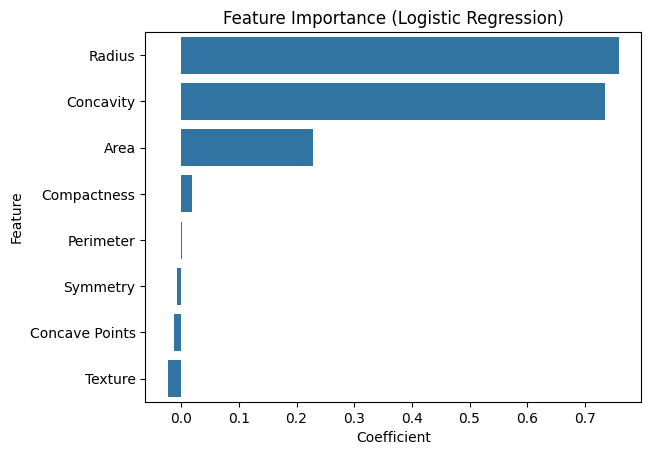

In [42]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

#Visualization
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Feature Importance (Logistic Regression)')
plt.show()

#**Random Forest**

#*Train-Test Split*

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#*Train Random Forest (Baseline)*

In [46]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

#*Prediction*

In [47]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

#*Model Evaluation*

In [48]:
#Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.764


In [50]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.91      0.85       734
           1       0.60      0.35      0.44       266

    accuracy                           0.76      1000
   macro avg       0.70      0.63      0.65      1000
weighted avg       0.74      0.76      0.74      1000



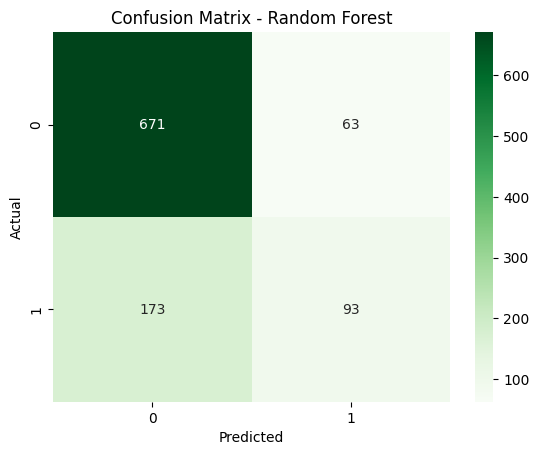

In [51]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

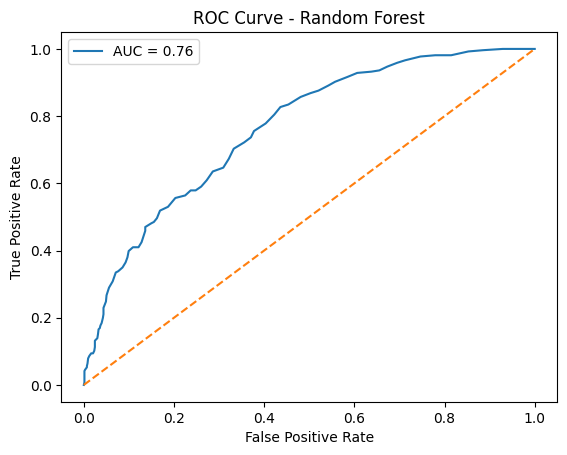

In [52]:
#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

#*Feature Importance*

          Feature  Importance
5       Concavity    0.170945
2            Area    0.146168
0          Radius    0.146081
3       Perimeter    0.134908
4     Compactness    0.104620
1         Texture    0.101557
7        Symmetry    0.098951
6  Concave Points    0.096769


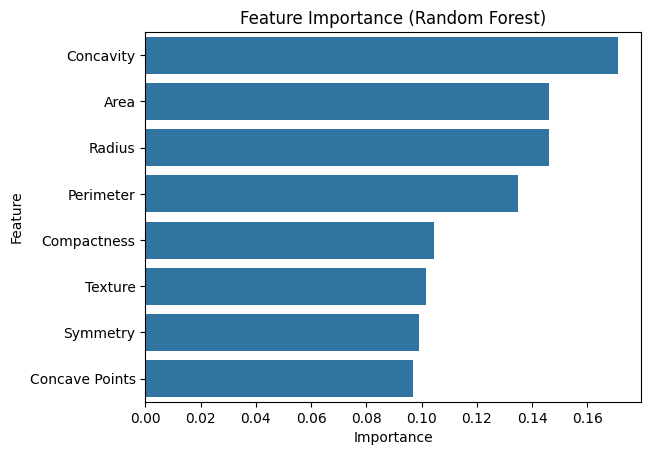

In [54]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

#Visualization
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance (Random Forest)')
plt.show()

Based on the evaluation results, both models showed relatively balanced performance with insignificant differences, where Logistic Regression was slightly superior in terms of accuracy (0.772) compared to Random Forest (0.764). However, when focusing on the malignant class which is a priority in the medical context, both models still had fairly similar limitations, especially in the recall value which only reached 0.35, which indicated that the model was not able to optimally detect most malignant cancer cases. Although Logistic Regression had a slightly higher precision (0.63) and F1-score (0.45) than Random Forest (precision 0.6 and F1-score 0.44), these differences were not significant enough to indicate a strong superiority of either model. In terms of feature interpretation, both models consistently identified radius, concavity, and area as the most influential factors, which strengthens the finding that cell size and shape characteristics play an important role in breast cancer classification. Overall, although Logistic Regression performed slightly better, both models still require further improvement, particularly in enhancing the recall of malignant cases to be more reliable in real-world scenarios.

Based on the ROC curves of the two models that have been created, the Logistic Regression model has a slightly superior performance compared to Random Forest in classifying breast cancer cases, as seen from the AUC (Area Under Curve) value of 0.80 compared to 0.76. Visually, the Logistic Regression curve tends to be closer to the upper left corner of the graph, which indicates a better model ability in balancing the levels of sensitivity (True Positive Rate) and specificity (False Positive Rate). With an AUC difference of 0.04, Logistic Regression has a higher probability of distinguishing between patients who actually have cancer and those who do not, making it a more optimal choice for this case if only based on the ROC curve metric.